# Figures & Tables
## Short-Horizon Safety Forecasting for Wildfire Operations


In [40]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PROJECT_ROOT = Path(r'C:\Users\horhe\OneDrive\Documents\DSS\wildfire_dss')
RESULTS_DIR = PROJECT_ROOT / 'results'
CONFIGS_DIR = PROJECT_ROOT / 'configs'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
DATA_DIR    = PROJECT_ROOT / 'data'

# Loading Data
with open(RESULTS_DIR / 'test_metrics.json') as f:
    test_metrics = json.load(f)

training_log = pd.read_csv(OUTPUTS_DIR / 'convlstm_v3_6crews' / 'logs' / 'training_log.csv')

with open(DATA_DIR / 'raw' / 'audit_summary.json') as f:
    audit_summary = json.load(f)

# Loading Hyperparameter Tuning Data
hp_trials = []
tuner_dir = OUTPUTS_DIR / 'tuning' / 'convlstm_bayesian'
for trial_dir in sorted(tuner_dir.glob('trial_*')):
    trial_json = trial_dir / 'trial.json'
    if trial_json.exists():
        with open(trial_json) as f:
            trial_data = json.load(f)
        if trial_data.get('status') == 'COMPLETED':
            hp = trial_data['hyperparameters']['values']
            score = trial_data.get('score')
            hp_trials.append({**hp, 'val_auc': score, 'trial_id': trial_dir.name})

print(f"Loaded: {len(training_log)} training epochs, "
      f"{len(hp_trials)} HP trials, "
      f"test metrics for {test_metrics['overall']['num_crews']} crews")

# Color Palette
BLUE          = '#003366'    
BLUE_DARK     = '#002244'    
BLUE_MID      = '#004D99'    
BLUE_LIGHT    = '#0066CC'   
BLUE_PALE     = '#336699'    
BLUE_WASH     = '#6699CC'    
ACCENT_GOLD = '#CC8800'    
GREY_MID    = '#7F8C8D'   

# Other Colors
RED_DANGER = '#CC3333'
GREEN_SAFE = '#339966'

# Graphing Parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
    'axes.edgecolor': BLUE,
    'axes.labelcolor': BLUE,
    'xtick.color': BLUE,
    'ytick.color': BLUE,
    'text.color': BLUE,
    'axes.linewidth': 0.8,
})

# Output directory for figures
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Loaded: 20 training epochs, 11 HP trials, test metrics for 6 crews
Setup complete.


---
## Figure 1: Research Pipeline Overview 

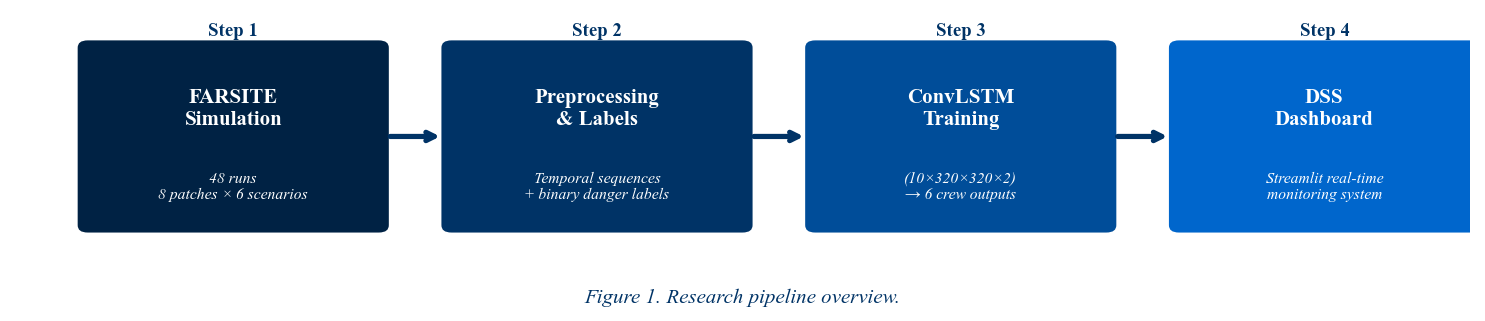

In [36]:
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2.2)
ax.axis('off')

steps = [
    {'label': 'Step 1', 'title': 'FARSITE\nSimulation', 'sub': '48 runs\n8 patches × 6 scenarios',
     'x': 0.5, 'color': BLUE_DARK},
    {'label': 'Step 2', 'title': 'Preprocessing\n& Labels', 'sub': 'Temporal sequences\n+ binary danger labels',
     'x': 3.0, 'color': BLUE},
    {'label': 'Step 3', 'title': 'ConvLSTM\nTraining', 'sub': '(10×320×320×2)\n→ 6 crew outputs',
     'x': 5.5, 'color': BLUE_MID},
    {'label': 'Step 4', 'title': 'DSS\nDashboard', 'sub': 'Streamlit real-time\nmonitoring system',
     'x': 8.0, 'color': BLUE_LIGHT},
]

box_w, box_h = 2.0, 1.6
for s in steps:
    rect = FancyBboxPatch((s['x'], 0.3), box_w, box_h, boxstyle='round,pad=0.08',
                          facecolor=s['color'], edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(s['x'] + box_w/2, 2.05, s['label'], ha='center', va='center',
            fontsize=9, fontweight='bold', color=BLUE)
    ax.text(s['x'] + box_w/2, 1.35, s['title'], ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(s['x'] + box_w/2, 0.65, s['sub'], ha='center', va='center',
            fontsize=7.5, color='white', style='italic')

for i in range(3):
    x_start = steps[i]['x'] + box_w + 0.05
    x_end = steps[i+1]['x'] - 0.05
    ax.annotate('', xy=(x_end, 1.1), xytext=(x_start, 1.1),
                arrowprops=dict(arrowstyle='->', color=BLUE, lw=2.5))

fig.suptitle('Figure 1. Research pipeline overview.', y=-0.02, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_pipeline.png', bbox_inches='tight')
plt.show()

---
## Figure 2: Patch Spatial Distribution Map

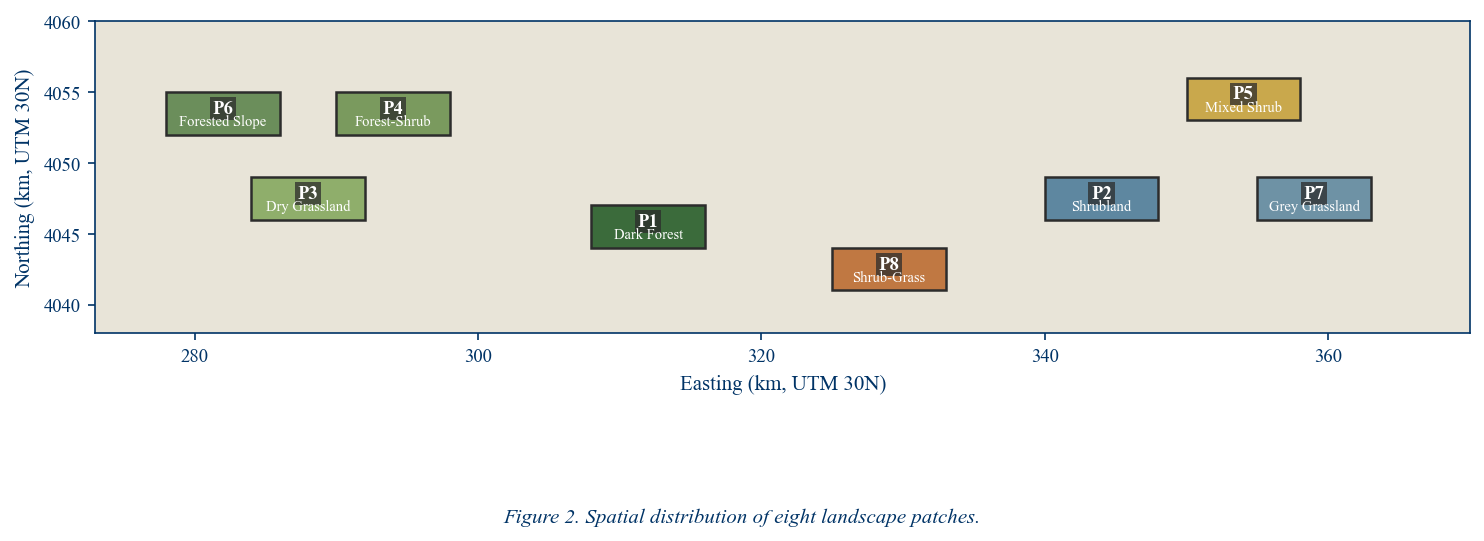

In [39]:
patches_map = {
    'P6': {'x': 278, 'y': 4052, 'w': 8, 'h': 3, 'label': 'Forested Slope', 'color': '#6B8E5B'},
    'P4': {'x': 290, 'y': 4052, 'w': 8, 'h': 3, 'label': 'Forest-Shrub',   'color': '#7A9A5E'},
    'P3': {'x': 284, 'y': 4046, 'w': 8, 'h': 3, 'label': 'Dry Grassland',  'color': '#8FAE6B'},
    'P1': {'x': 308, 'y': 4044, 'w': 8, 'h': 3, 'label': 'Dark Forest',    'color': '#3B6B3B'},
    'P8': {'x': 325, 'y': 4041, 'w': 8, 'h': 3, 'label': 'Shrub-Grass',    'color': '#C07842'},
    'P2': {'x': 340, 'y': 4046, 'w': 8, 'h': 3, 'label': 'Shrubland',      'color': '#5E87A0'},
    'P7': {'x': 355, 'y': 4046, 'w': 8, 'h': 3, 'label': 'Grey Grassland', 'color': '#6E92A5'},
    'P5': {'x': 350, 'y': 4053, 'w': 8, 'h': 3, 'label': 'Mixed Shrub',    'color': '#C9A84C'},
}

fig, ax = plt.subplots(figsize=(10, 4.5))

for pid, p in patches_map.items():
    rect = FancyBboxPatch(
        (p['x'], p['y']), p['w'], p['h'],
        boxstyle='square,pad=0',
        facecolor=p['color'], edgecolor='#2C2C2C', linewidth=1.2,
    )
    ax.add_patch(rect)
    cx = p['x'] + p['w'] / 2
    cy = p['y'] + p['h'] / 2
    ax.text(cx, cy + 0.35, pid, ha='center', va='center',
            fontweight='bold', fontsize=9, color='white',
            bbox=dict(boxstyle='square,pad=0.15', facecolor='#2C2C2C',
                      edgecolor='none', alpha=0.75))
    ax.text(cx, cy - 0.55, p['label'], ha='center', va='center',
            fontsize=7, color='white')

ax.set_xlim(273, 370)
ax.set_ylim(4038, 4060)
ax.set_aspect('equal')
ax.set_xlabel('Easting (km, UTM 30N)', fontsize=10)
ax.set_ylabel('Northing (km, UTM 30N)', fontsize=10)
ax.set_facecolor('#E8E4D8')
ax.grid(False)

fig.suptitle('Figure 2. Spatial distribution of eight landscape patches.',
             y=-0.02, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_patches.png', bbox_inches='tight')
plt.show()

---
## Figure 3: Fire Spread Across 6 Weather Scenarios

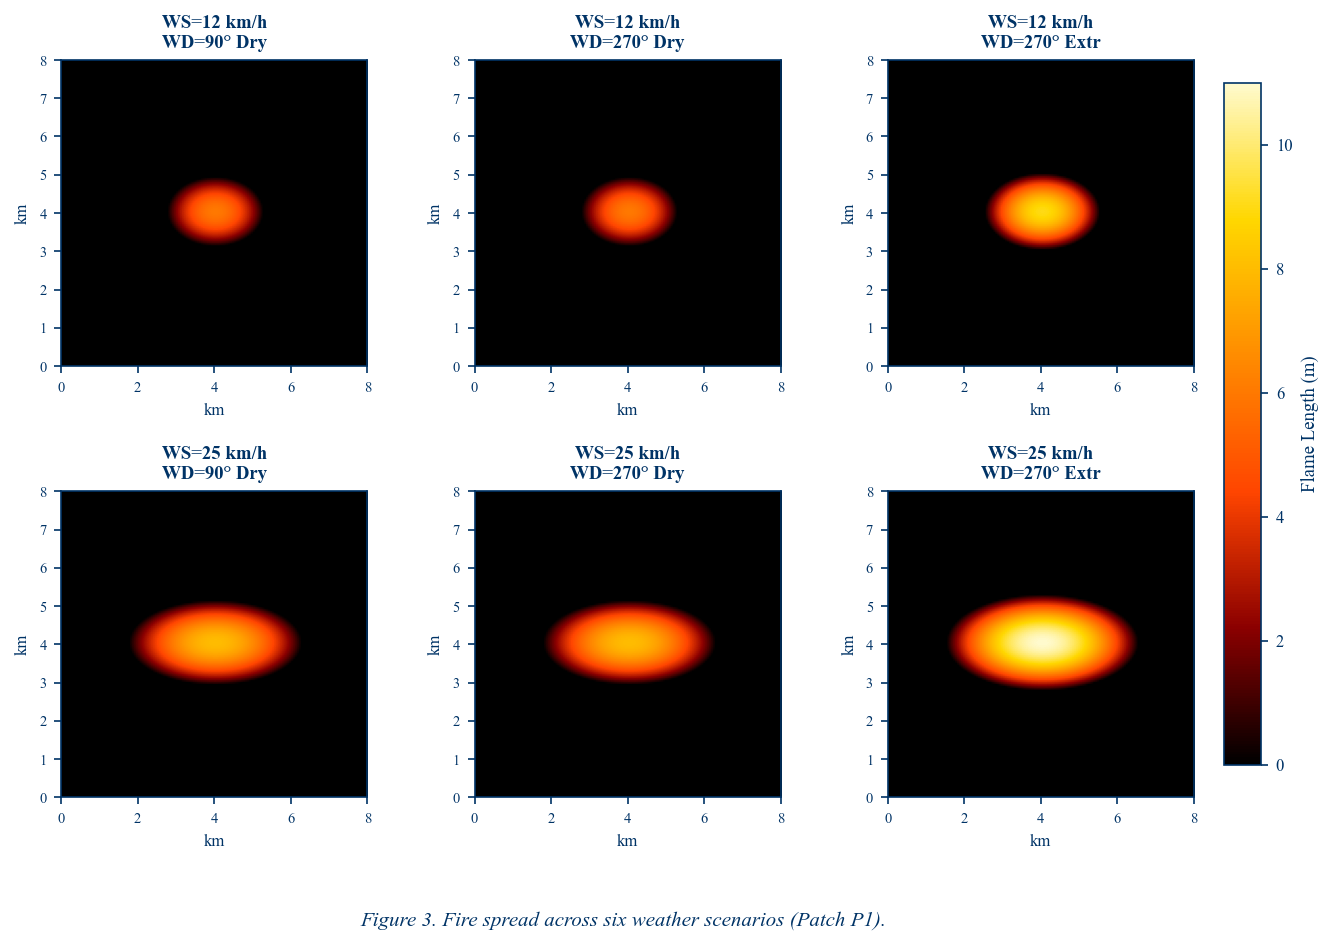

In [ ]:
def make_fire_ellipse(shape=(160, 160), cx=80, cy=80, a=30, b=20, angle=0, intensity=8.0):
    """Simulate a fire spread ellipse (flame length heatmap)."""
    y, x = np.ogrid[:shape[0], :shape[1]]
    cos_a, sin_a = np.cos(np.radians(angle)), np.sin(np.radians(angle))
    xr = cos_a * (x - cx) + sin_a * (y - cy)
    yr = -sin_a * (x - cx) + cos_a * (y - cy)
    dist = (xr / a)**2 + (yr / b)**2
    fire = np.where(dist <= 1.0, intensity * (1 - dist), 0)
    return fire

scenarios = [
    ('WS=12 km/h\nWD=90\u00b0 Dry',   {'a': 25, 'b': 18, 'angle': 0, 'intensity': 6}),
    ('WS=12 km/h\nWD=270\u00b0 Dry',  {'a': 25, 'b': 18, 'angle': 180, 'intensity': 6}),
    ('WS=12 km/h\nWD=270\u00b0 Extr', {'a': 30, 'b': 20, 'angle': 180, 'intensity': 9}),
    ('WS=25 km/h\nWD=90\u00b0 Dry',   {'a': 45, 'b': 22, 'angle': 0, 'intensity': 8}),
    ('WS=25 km/h\nWD=270\u00b0 Dry',  {'a': 45, 'b': 22, 'angle': 180, 'intensity': 8}),
    ('WS=25 km/h\nWD=270\u00b0 Extr', {'a': 50, 'b': 25, 'angle': 180, 'intensity': 11}),
]

fire_cmap = LinearSegmentedColormap.from_list('fire',
    ['#000000', '#8B0000', '#FF4500', '#FF8C00', '#FFD700', '#FFFACD'], N=256)

fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for idx, (title, params) in enumerate(scenarios):
    ax = axes[idx // 3, idx % 3]
    fire = make_fire_ellipse(**params)
    im = ax.imshow(fire, cmap=fire_cmap, vmin=0, vmax=11, origin='lower',
                   extent=[0, 8, 0, 8])
    ax.set_title(title, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('km', fontsize=8)
    ax.set_ylabel('km', fontsize=8)
    ax.tick_params(labelsize=7)

fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.35)
cbar_ax = fig.add_axes([0.90, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Flame Length (m)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle('Figure 3. Fire spread across six weather scenarios (Patch P1).',
             y=0.0, fontsize=10, style='italic')
plt.savefig(FIG_DIR / 'fig3_fire_scenarios.png', bbox_inches='tight')
plt.show()

---
## Figure 4: Label Creation Process

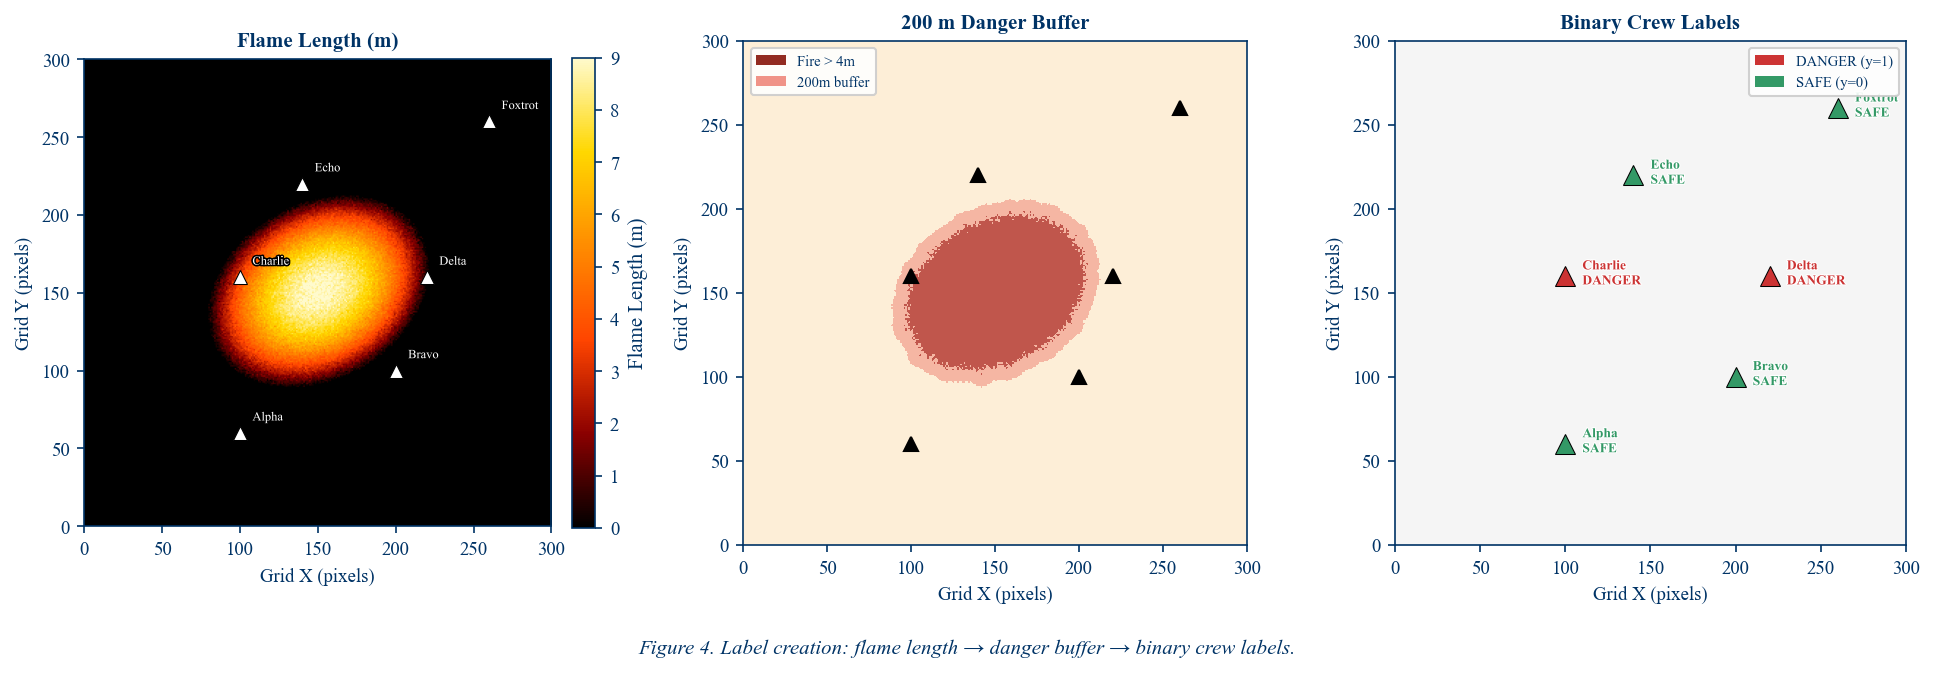

In [ ]:
np.random.seed(42)

fire = make_fire_ellipse(shape=(320, 320), cx=160, cy=160, a=80, b=60, angle=30, intensity=9.0)
fire += np.random.normal(0, 0.3, fire.shape) * (fire > 0)
fire = np.clip(fire, 0, None)

danger_zone = (fire > 4.0).astype(float)
from scipy.ndimage import distance_transform_edt
try:
    dist_from_danger = distance_transform_edt(1 - danger_zone)
    buffer_zone = (dist_from_danger <= 8).astype(float)  
except:
    buffer_zone = danger_zone 

crews = {
    'Alpha':   (60, 100),
    'Bravo':   (100, 200),
    'Charlie': (160, 100),
    'Delta':   (160, 220),
    'Echo':    (220, 140),
    'Foxtrot': (260, 260),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

ax1 = axes[0]
im1 = ax1.imshow(fire, cmap=fire_cmap, vmin=0, vmax=9, origin='lower', extent=[0, 300, 0, 300])
for name, (cy, cx) in crews.items():
    ax1.plot(cx, cy, '^', color='white', markersize=7, markeredgecolor='black', markeredgewidth=0.5)
    ax1.text(cx+8, cy+8, name, fontsize=6, color='white',
             path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
ax1.set_title('Flame Length (m)', fontweight='bold', fontsize=10)
ax1.set_xlabel('Grid X (pixels)', fontsize=9)
ax1.set_ylabel('Grid Y (pixels)', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Flame Length (m)')

ax2 = axes[1]
buffer_cmap = LinearSegmentedColormap.from_list('buf', ['#FDEBD0', '#E74C3C'], N=2)
ax2.imshow(buffer_zone, cmap=buffer_cmap, origin='lower', extent=[0, 300, 0, 300], alpha=0.7)
ax2.imshow(danger_zone, cmap=LinearSegmentedColormap.from_list('dz', ['#FDEBD0', '#922B21'], N=2),
           origin='lower', extent=[0, 300, 0, 300], alpha=0.5)
for name, (cy, cx) in crews.items():
    ax2.plot(cx, cy, '^', color='black', markersize=7)
ax2.set_title('200 m Danger Buffer', fontweight='bold', fontsize=10)
ax2.set_xlabel('Grid X (pixels)', fontsize=9)
ax2.set_ylabel('Grid Y (pixels)', fontsize=9)

from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor='#922B21', label='Fire > 4m'),
    mpatches.Patch(facecolor='#E74C3C', alpha=0.6, label='200m buffer'),
]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.9)

ax3 = axes[2]
ax3.set_xlim(0, 300)
ax3.set_ylim(0, 300)
ax3.set_facecolor('#F5F5F5')
for name, (cy, cx) in crews.items():
    gy, gx = min(cy, 319), min(cx, 319)
    in_danger = buffer_zone[gy, gx] > 0.5
    color = RED_DANGER if in_danger else GREEN_SAFE
    label = 'DANGER' if in_danger else 'SAFE'
    marker_color = color
    ax3.plot(cx, cy, '^', color=marker_color, markersize=10, markeredgecolor='black', markeredgewidth=0.5)
    ax3.text(cx+10, cy-5, f'{name}\n{label}', fontsize=6.5, fontweight='bold', color=color,
             path_effects=[pe.withStroke(linewidth=1, foreground='white')])

ax3.set_title('Binary Crew Labels', fontweight='bold', fontsize=10)
ax3.set_xlabel('Grid X (pixels)', fontsize=9)
ax3.set_ylabel('Grid Y (pixels)', fontsize=9)
legend_elements2 = [
    mpatches.Patch(facecolor=RED_DANGER, label='DANGER (y=1)'),
    mpatches.Patch(facecolor=GREEN_SAFE, label='SAFE (y=0)'),
]
ax3.legend(handles=legend_elements2, loc='upper right', fontsize=7, framealpha=0.9)

fig.suptitle('Figure 4. Label creation: flame length \u2192 danger buffer \u2192 binary crew labels.',
             y=-0.02, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_label_creation.png', bbox_inches='tight')
plt.show()

---
## Figure 5: ConvLSTM Architecture

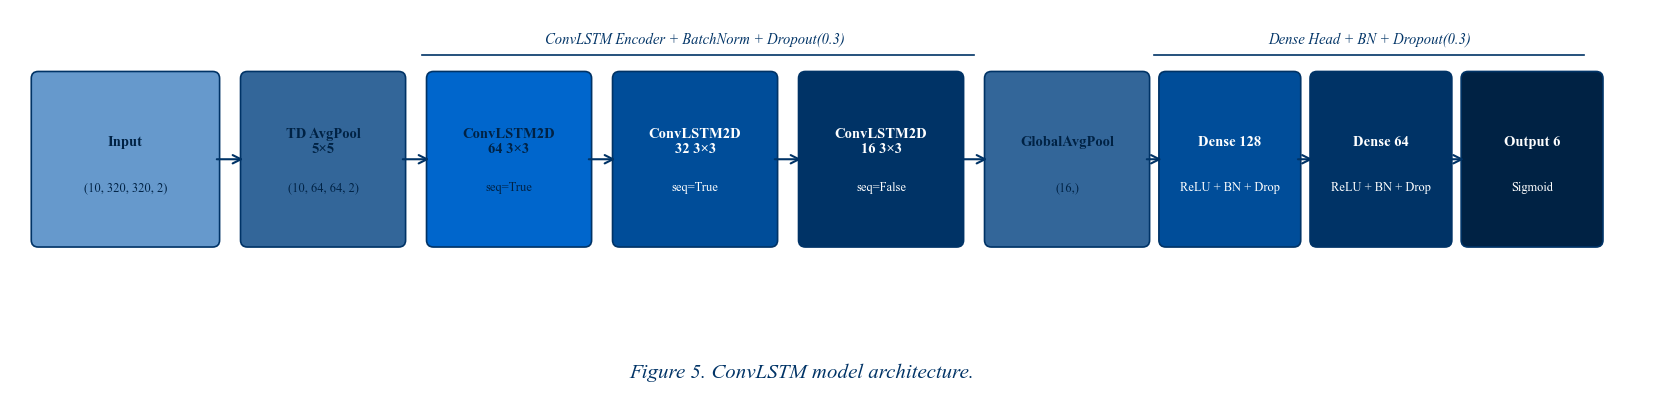

In [6]:
fig, ax = plt.subplots(figsize=(14, 2.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 2.5)
ax.axis('off')

layers = [
    {'name': 'Input',             'sub': '(10, 320, 320, 2)', 'x': 0.2,  'w': 1.5, 'color': BLUE_WASH},
    {'name': 'TD AvgPool\n5\u00d75',  'sub': '(10, 64, 64, 2)',   'x': 2.0,  'w': 1.3, 'color': BLUE_PALE},
    {'name': 'ConvLSTM2D\n64 3\u00d73', 'sub': 'seq=True',       'x': 3.6,  'w': 1.3, 'color': BLUE_LIGHT},
    {'name': 'ConvLSTM2D\n32 3\u00d73', 'sub': 'seq=True',       'x': 5.2,  'w': 1.3, 'color': BLUE_MID},
    {'name': 'ConvLSTM2D\n16 3\u00d73', 'sub': 'seq=False',      'x': 6.8,  'w': 1.3, 'color': BLUE},
    {'name': 'GlobalAvgPool',     'sub': '(16,)',               'x': 8.4,  'w': 1.3, 'color': BLUE_PALE},
    {'name': 'Dense 128',         'sub': 'ReLU + BN + Drop',    'x': 9.9,  'w': 1.1, 'color': BLUE_MID},
    {'name': 'Dense 64',          'sub': 'ReLU + BN + Drop',    'x': 11.2, 'w': 1.1, 'color': BLUE},
    {'name': 'Output 6',          'sub': 'Sigmoid',             'x': 12.5, 'w': 1.1, 'color': BLUE_DARK},
]

_white_text = {BLUE_DARK, BLUE, BLUE_MID}

box_h = 1.4
y0 = 0.55

for i, l in enumerate(layers):
    rect = FancyBboxPatch((l['x'], y0), l['w'], box_h, boxstyle='round,pad=0.06',
                          facecolor=l['color'], edgecolor=BLUE, linewidth=0.8)
    ax.add_patch(rect)
    tc = 'white' if l['color'] in _white_text else BLUE_DARK
    ax.text(l['x'] + l['w']/2, y0 + box_h/2 + 0.15, l['name'],
            ha='center', va='center', fontsize=7, fontweight='bold', color=tc)
    ax.text(l['x'] + l['w']/2, y0 + box_h/2 - 0.25, l['sub'],
            ha='center', va='center', fontsize=6, color=tc)
    if i < len(layers) - 1:
        x_end = layers[i+1]['x']
        x_start = l['x'] + l['w']
        ax.annotate('', xy=(x_end, y0 + box_h/2), xytext=(x_start, y0 + box_h/2),
                    arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))

ax.plot([3.5, 8.25], [2.15, 2.15], color=BLUE, lw=0.8)
ax.text(5.85, 2.25, 'ConvLSTM Encoder + BatchNorm + Dropout(0.3)',
        ha='center', fontsize=7, style='italic', color=BLUE)
ax.plot([9.8, 13.5], [2.15, 2.15], color=BLUE, lw=0.8)
ax.text(11.65, 2.25, 'Dense Head + BN + Dropout(0.3)', ha='center', fontsize=7, style='italic', color=BLUE)

fig.suptitle('Figure 5. ConvLSTM model architecture.', y=-0.05, fontsize=10, style='italic')
plt.savefig(FIG_DIR / 'fig5_architecture.png', bbox_inches='tight')
plt.show()

---
## Figure 6: Operational Alert Level Scheme

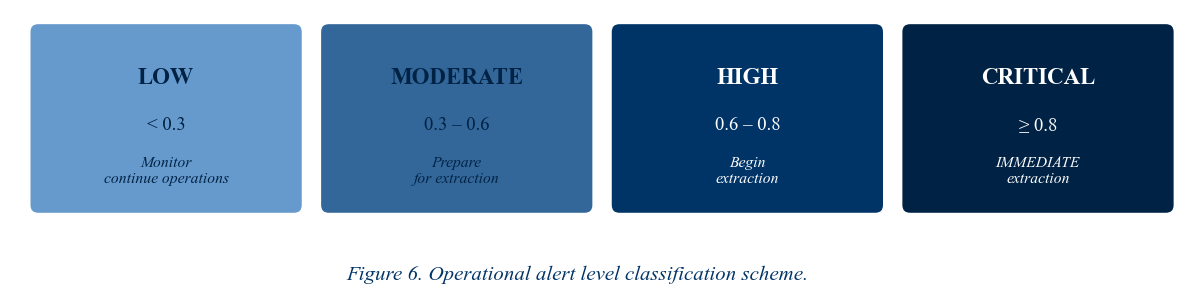

In [8]:
fig, ax = plt.subplots(figsize=(10, 1.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.8)
ax.axis('off')

alert_levels = [
    {'label': 'LOW', 'thresh': '< 0.3', 'action': 'Monitor\ncontinue operations',
     'x': 0.2, 'color': BLUE_WASH},
    {'label': 'MODERATE', 'thresh': '0.3 \u2013 0.6', 'action': 'Prepare\nfor extraction',
     'x': 2.7, 'color': BLUE_PALE},
    {'label': 'HIGH', 'thresh': '0.6 \u2013 0.8', 'action': 'Begin\nextraction',
     'x': 5.2, 'color': BLUE},
    {'label': 'CRITICAL', 'thresh': '\u2265 0.8', 'action': 'IMMEDIATE\nextraction',
     'x': 7.7, 'color': BLUE_DARK},
]

bw, bh = 2.2, 1.5

_dark_boxes = {BLUE, BLUE_DARK}
for a in alert_levels:
    rect = FancyBboxPatch((a['x'], 0.15), bw, bh, boxstyle='round,pad=0.08',
                          facecolor=a['color'], edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    tc = 'white' if a['color'] in _dark_boxes else BLUE_DARK
    ax.text(a['x'] + bw/2, 1.25, a['label'], ha='center', va='center',
            fontsize=11, fontweight='bold', color=tc)
    ax.text(a['x'] + bw/2, 0.85, a['thresh'], ha='center', va='center',
            fontsize=9, color=tc)
    ax.text(a['x'] + bw/2, 0.45, a['action'], ha='center', va='center',
            fontsize=7.5, color=tc, style='italic')

fig.suptitle('Figure 6. Operational alert level classification scheme.',
             y=-0.05, fontsize=10, style='italic')
plt.savefig(FIG_DIR / 'fig6_alert_levels.png', bbox_inches='tight')
plt.show()

---
## Figure R1: Training Convergence (Loss & AUC-ROC)

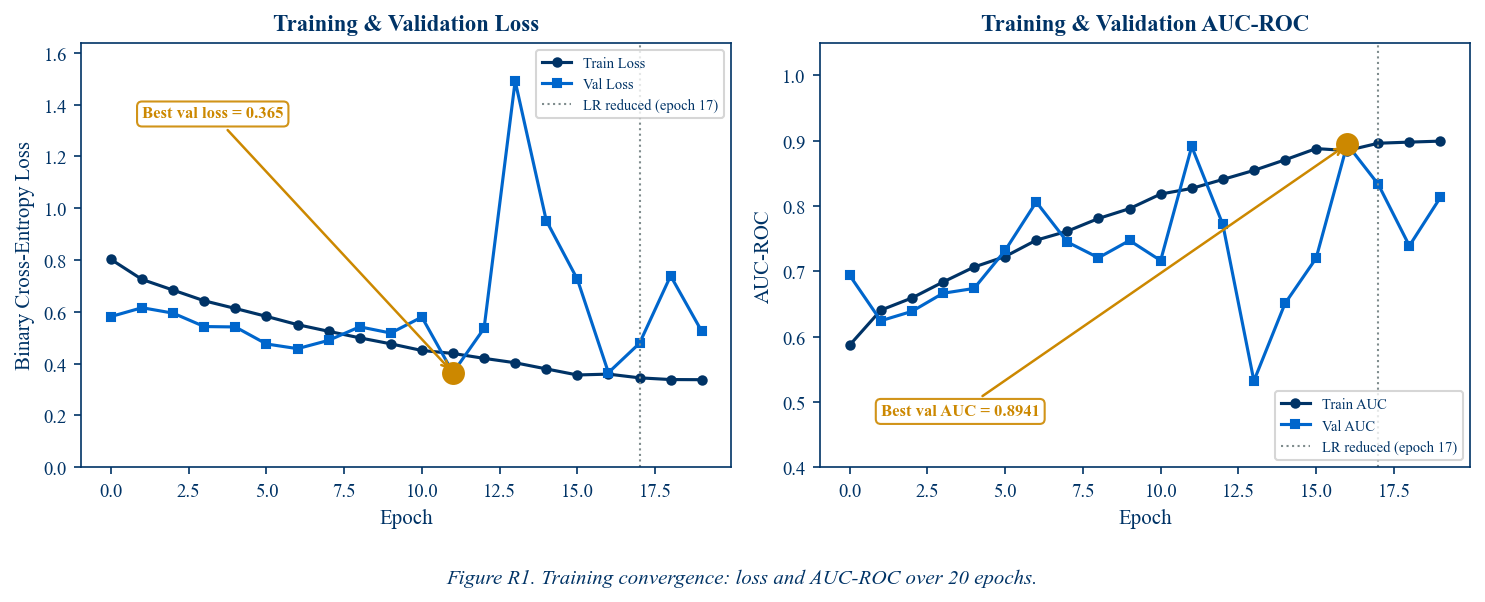

In [42]:
epochs = training_log['epoch'].values
train_loss = training_log['loss'].values
val_loss   = training_log['val_loss'].values
train_auc  = training_log['auc'].values
val_auc    = training_log['val_auc'].values
lr_values  = training_log['learning_rate'].values

lr_reduce_epoch = None
for i in range(1, len(lr_values)):
    if lr_values[i] < lr_values[i-1]:
        lr_reduce_epoch = i
        break

best_epoch = int(np.argmin(val_loss))
best_auc_epoch = int(np.argmax(val_auc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Loss ---
ax1.plot(epochs, train_loss, '-o', color=BLUE, markersize=4, linewidth=1.5, label='Train Loss')
ax1.plot(epochs, val_loss, '-s', color=BLUE_LIGHT, markersize=4, linewidth=1.5, label='Val Loss')
if lr_reduce_epoch is not None:
    ax1.axvline(lr_reduce_epoch, color=GREY_MID, linestyle=':', linewidth=1,
                label=f'LR reduced (epoch {lr_reduce_epoch})')
ax1.plot(best_epoch, val_loss[best_epoch], 'o', color=ACCENT_GOLD, markersize=10, zorder=5)
ax1.annotate(f'Best val loss = {val_loss[best_epoch]:.3f}', xy=(best_epoch, val_loss[best_epoch]),
             xytext=(1, 1.35),
             arrowprops=dict(arrowstyle='->', color=ACCENT_GOLD, lw=1.2),
             fontsize=8, fontweight='bold', color=ACCENT_GOLD,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=ACCENT_GOLD, alpha=0.9))
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.legend(fontsize=7, loc='upper right')
ax1.set_ylim(0, max(train_loss.max(), val_loss.max()) * 1.1)

# --- AUC ---
ax2.plot(epochs, train_auc, '-o', color=BLUE, markersize=4, linewidth=1.5, label='Train AUC')
ax2.plot(epochs, val_auc, '-s', color=BLUE_LIGHT, markersize=4, linewidth=1.5, label='Val AUC')
if lr_reduce_epoch is not None:
    ax2.axvline(lr_reduce_epoch, color=GREY_MID, linestyle=':', linewidth=1,
                label=f'LR reduced (epoch {lr_reduce_epoch})')
ax2.plot(best_auc_epoch, val_auc[best_auc_epoch], 'o', color=ACCENT_GOLD, markersize=10, zorder=5)
ax2.annotate(f'Best val AUC = {val_auc[best_auc_epoch]:.4f}', xy=(best_auc_epoch, val_auc[best_auc_epoch]),
             xytext=(1, 0.48),
             arrowprops=dict(arrowstyle='->', color=ACCENT_GOLD, lw=1.2),
             fontsize=8, fontweight='bold', color=ACCENT_GOLD,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=ACCENT_GOLD, alpha=0.9))
ax2.set_title('Training & Validation AUC-ROC', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.legend(fontsize=7, loc='lower right')
ax2.set_ylim(0.4, 1.05)

fig.suptitle('Figure R1. Training convergence: loss and AUC-ROC over 20 epochs.',
             y=-0.03, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figR1_training.png', bbox_inches='tight')
plt.show()

---
## Figure R2: Overall Test Metrics

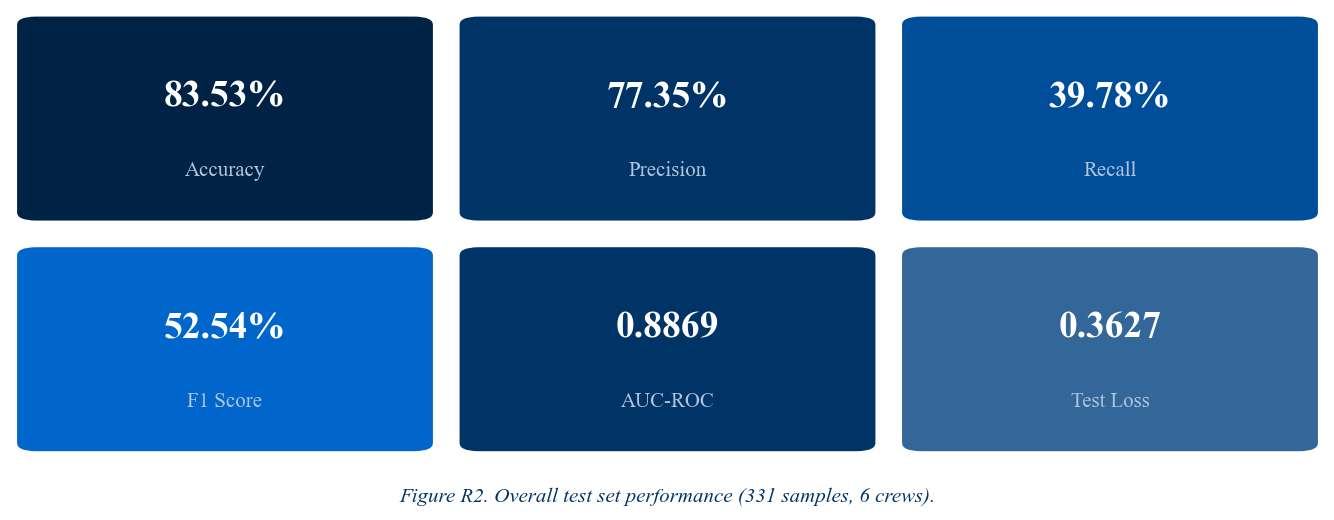

In [27]:
o = test_metrics['overall']
metrics_display = [
    (f"{o['accuracy']*100:.2f}%",  'Accuracy',  BLUE_DARK),
    (f"{o['precision']*100:.2f}%", 'Precision',  BLUE),
    (f"{o['recall']*100:.2f}%",    'Recall',     BLUE_MID),
    (f"{o['f1_score']*100:.2f}%",  'F1 Score',   BLUE_LIGHT),
    (f"{o['auc_roc']:.4f}",        'AUC-ROC',    BLUE),
    (f"{test_metrics['keras_metrics']['loss']:.4f}", 'Test Loss', BLUE_PALE),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 3.5))
for idx, (val, name, box_color) in enumerate(metrics_display):
    ax = axes[idx // 3, idx % 3]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    rect = FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle='round,pad=0.05',
                          facecolor=box_color, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(0.5, 0.6, val, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(0.5, 0.25, name, ha='center', va='center',
            fontsize=10, color='#B0C4DE')

fig.suptitle(f'Figure R2. Overall test set performance ({o["num_samples"]} samples, {o["num_crews"]} crews).',
             y=-0.02, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figR2_test_metrics.png', bbox_inches='tight')
plt.show()

---
## Figure R3: Per-Crew Breakdown (Precision/Recall, AUC, Danger Rate)

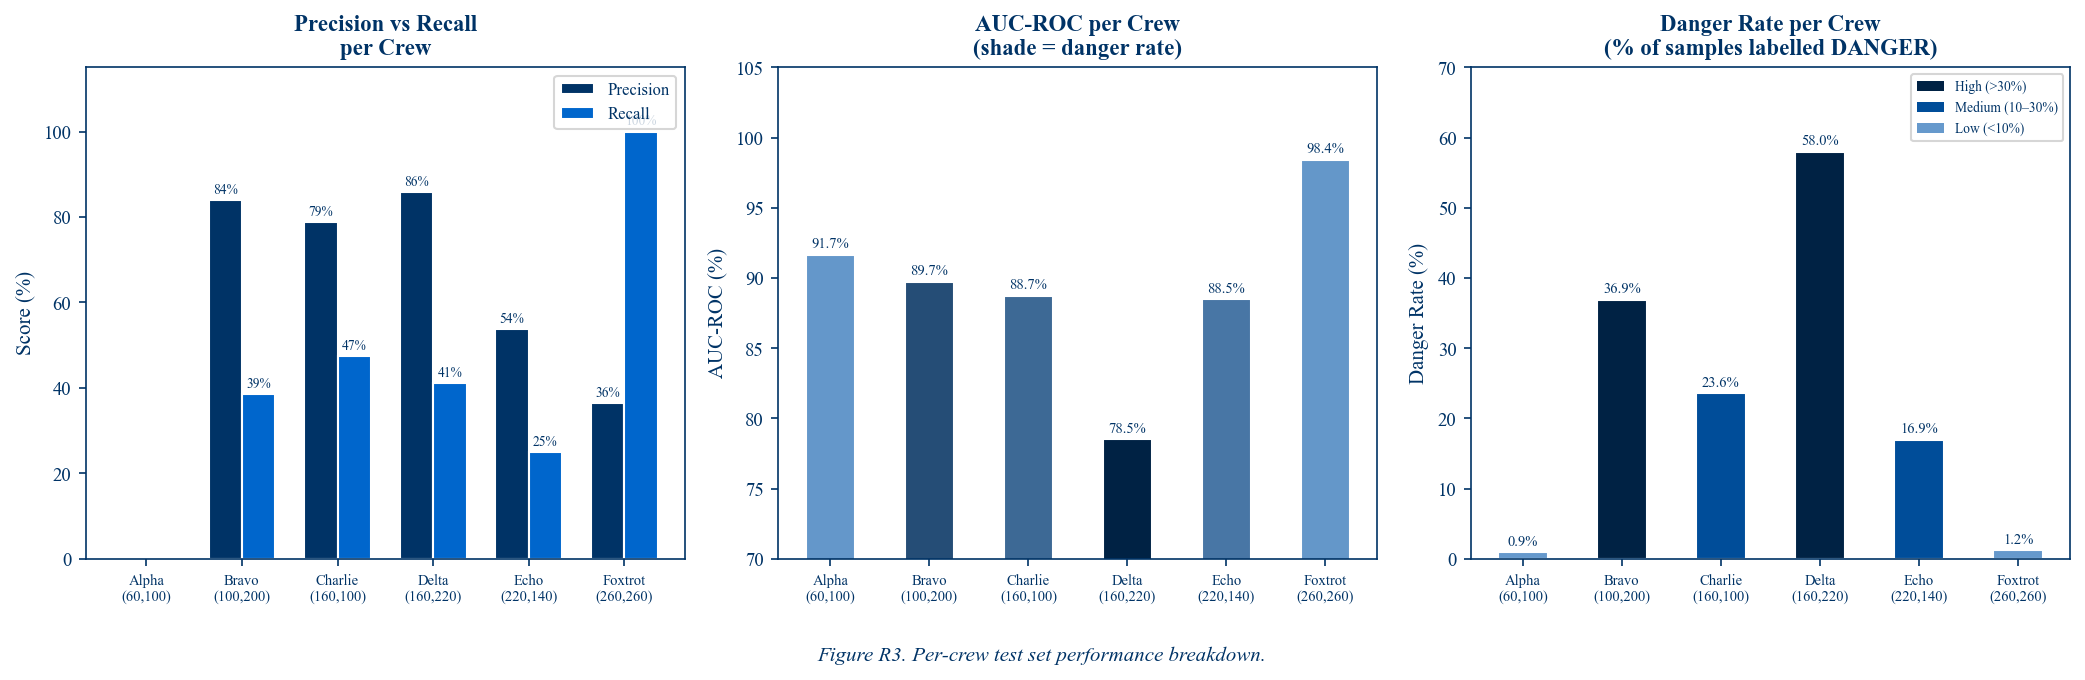

In [11]:
crew_data = test_metrics['per_crew']
crew_keys = list(crew_data.keys()) 
crew_short = [k.split(' (')[0] for k in crew_keys]
crew_labels = [f"{k.split(' (')[0]}\n({k.split('(')[1]}" for k in crew_keys]

precision_vals = [crew_data[k]['precision'] * 100 for k in crew_keys]
recall_vals    = [crew_data[k]['recall'] * 100 for k in crew_keys]
auc_vals       = [crew_data[k]['auc_roc'] for k in crew_keys]
danger_rates   = [crew_data[k]['danger_rate'] * 100 for k in crew_keys]

x = np.arange(len(crew_labels))
bar_w = 0.35

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5))

bars1 = ax1.bar(x - bar_w/2, precision_vals, bar_w, label='Precision', color=BLUE, edgecolor='white')
bars2 = ax1.bar(x + bar_w/2, recall_vals, bar_w, label='Recall', color=BLUE_LIGHT, edgecolor='white')
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', fontsize=6.5)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', fontsize=6.5)
ax1.set_xticks(x)
ax1.set_xticklabels(crew_labels, fontsize=7)
ax1.set_ylabel('Score (%)')
ax1.set_title('Precision vs Recall\nper Crew', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 115)

norm_dr = np.array(danger_rates) / max(max(danger_rates), 1)
ie_cmap = LinearSegmentedColormap.from_list('ie_blues', [BLUE_WASH, BLUE_DARK], N=256)
colors_auc = [ie_cmap(v) for v in norm_dr]

bars3 = ax2.bar(x, [v * 100 for v in auc_vals], 0.5, color=colors_auc, edgecolor='white')
for bar, v in zip(bars3, auc_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v*100:.1f}%', ha='center', fontsize=7)
ax2.set_xticks(x)
ax2.set_xticklabels(crew_labels, fontsize=7)
ax2.set_ylabel('AUC-ROC (%)')
ax2.set_title('AUC-ROC per Crew\n(shade = danger rate)', fontweight='bold')
ax2.set_ylim(70, 105)

dr_colors = []
for d in danger_rates:
    if d > 30:
        dr_colors.append(BLUE_DARK)
    elif d > 10:
        dr_colors.append(BLUE_MID)
    else:
        dr_colors.append(BLUE_WASH)

bars4 = ax3.bar(x, danger_rates, 0.5, color=dr_colors, edgecolor='white')
for bar, v in zip(bars4, danger_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}%', ha='center', fontsize=7)
ax3.set_xticks(x)
ax3.set_xticklabels(crew_labels, fontsize=7)
ax3.set_ylabel('Danger Rate (%)')
ax3.set_title('Danger Rate per Crew\n(% of samples labelled DANGER)', fontweight='bold')
ax3.set_ylim(0, 70)
legend_dr = [
    mpatches.Patch(facecolor=BLUE_DARK, label='High (>30%)'),
    mpatches.Patch(facecolor=BLUE_MID, label='Medium (10\u201330%)'),
    mpatches.Patch(facecolor=BLUE_WASH, label='Low (<10%)'),
]
ax3.legend(handles=legend_dr, fontsize=6.5, loc='upper right')

fig.suptitle('Figure R3. Per-crew test set performance breakdown.',
             y=-0.03, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figR3_per_crew.png', bbox_inches='tight')
plt.show()

---
## Figure R4: Threshold Sensitivity & Asymmetric Cost

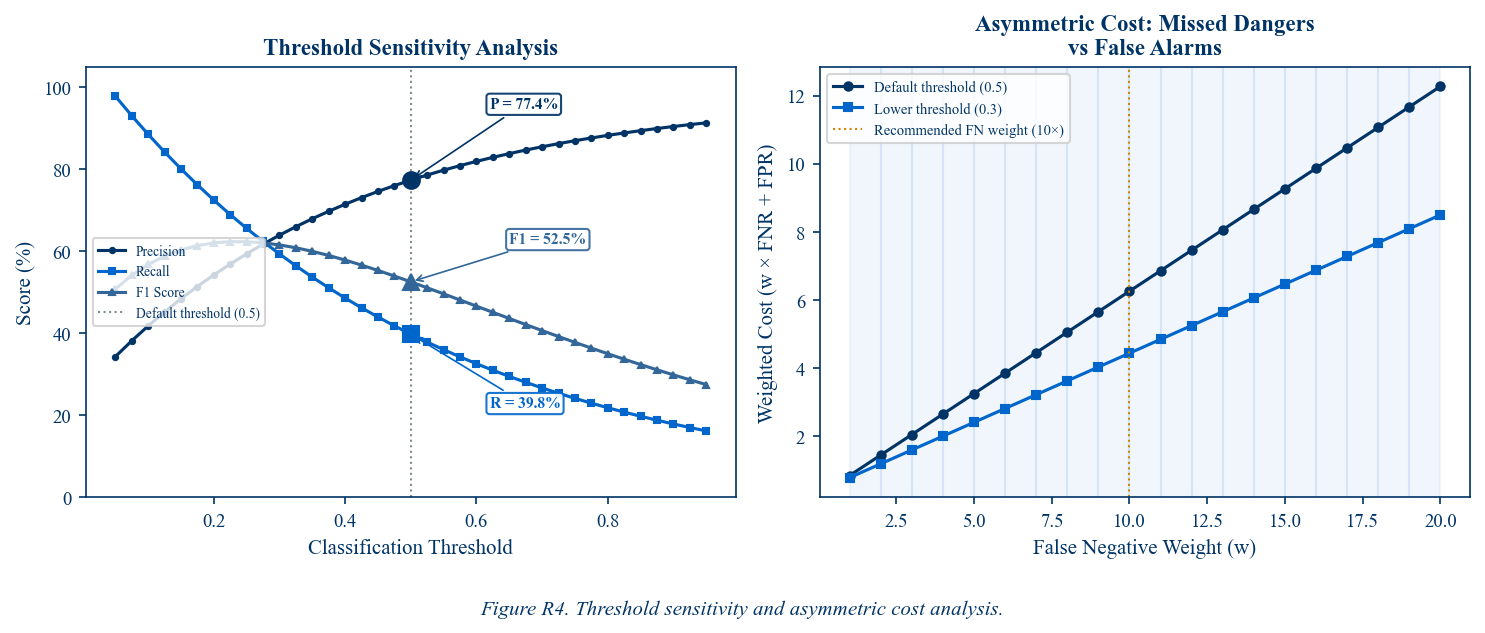

In [41]:
o = test_metrics['overall']
real_prec = o['precision'] * 100   
real_rec  = o['recall'] * 100      
real_f1   = o['f1_score'] * 100    

thresholds = np.linspace(0.05, 0.95, 37)

precision_curve = 25 + 70 * (1 - np.exp(-2.5 * thresholds))
p_at_05 = 25 + 70 * (1 - np.exp(-2.5 * 0.5))
precision_curve = precision_curve * (real_prec / p_at_05)
precision_curve = np.clip(precision_curve, 0, 100)

recall_curve = 98 * np.exp(-2.0 * thresholds)
r_at_05 = 98 * np.exp(-2.0 * 0.5)
recall_curve = recall_curve * (real_rec / r_at_05)
recall_curve = np.clip(recall_curve, 0, 100)

f1_curve = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

ax1.plot(thresholds, precision_curve, '-o', color=BLUE, markersize=2.5, linewidth=1.5, label='Precision')
ax1.plot(thresholds, recall_curve, '-s', color=BLUE_LIGHT, markersize=2.5, linewidth=1.5, label='Recall')
ax1.plot(thresholds, f1_curve, '-^', color=BLUE_PALE, markersize=2.5, linewidth=1.5, label='F1 Score')
ax1.axvline(0.5, color=GREY_MID, linestyle=':', linewidth=1, label='Default threshold (0.5)')

ax1.plot(0.5, real_prec, 'o', color=BLUE, markersize=8, zorder=6)
ax1.plot(0.5, real_rec, 's', color=BLUE_LIGHT, markersize=8, zorder=6)
ax1.plot(0.5, real_f1, '^', color=BLUE_PALE, markersize=8, zorder=6)

ax1.annotate(f'P = {real_prec:.1f}%', xy=(0.5, real_prec), xytext=(0.62, 95),
             fontsize=7.5, fontweight='bold', color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.8),
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=BLUE, alpha=0.9))
ax1.annotate(f'R = {real_rec:.1f}%', xy=(0.5, real_rec), xytext=(0.62, 22),
             fontsize=7.5, fontweight='bold', color=BLUE_LIGHT,
             arrowprops=dict(arrowstyle='->', color=BLUE_LIGHT, lw=0.8),
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=BLUE_LIGHT, alpha=0.9))
ax1.annotate(f'F1 = {real_f1:.1f}%', xy=(0.5, real_f1), xytext=(0.65, 62),
             fontsize=7.5, fontweight='bold', color=BLUE_PALE,
             arrowprops=dict(arrowstyle='->', color=BLUE_PALE, lw=0.8),
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=BLUE_PALE, alpha=0.9))

ax1.set_xlabel('Classification Threshold')
ax1.set_ylabel('Score (%)')
ax1.set_title('Threshold Sensitivity Analysis', fontweight='bold')
ax1.legend(fontsize=6.5, loc='center left')
ax1.set_ylim(0, 105)

fn_weights = np.arange(1, 21)

fnr_default = 100 - real_rec
fpr_default = 100 - real_prec
cost_default = fn_weights * (fnr_default / 100) + (fpr_default / 100)

idx_03 = np.argmin(np.abs(thresholds - 0.3))
fnr_lower = (100 - recall_curve[idx_03]) / 100
fpr_lower = (100 - precision_curve[idx_03]) / 100
cost_lower = fn_weights * fnr_lower + fpr_lower

ax2.plot(fn_weights, cost_default, '-o', color=BLUE, markersize=4, linewidth=1.5,
         label='Default threshold (0.5)')
ax2.plot(fn_weights, cost_lower, '-s', color=BLUE_LIGHT, markersize=4, linewidth=1.5,
         label='Lower threshold (0.3)')
ax2.axvline(10, color=ACCENT_GOLD, linestyle=':', linewidth=1, label='Recommended FN weight (10\u00d7)')

for i in range(len(fn_weights) - 1):
    if cost_lower[i] < cost_default[i]:
        ax2.axvspan(fn_weights[i], fn_weights[i+1], alpha=0.06, color=BLUE_LIGHT)

ax2.set_xlabel('False Negative Weight (w)')
ax2.set_ylabel('Weighted Cost (w \u00d7 FNR + FPR)')
ax2.set_title('Asymmetric Cost: Missed Dangers\nvs False Alarms', fontweight='bold')
ax2.legend(fontsize=7)

fig.suptitle('Figure R4. Threshold sensitivity and asymmetric cost analysis.',
             y=-0.03, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figR4_threshold.png', bbox_inches='tight')
plt.show()

---
## Figure R5: Bayesian Hyperparamter Tuning 

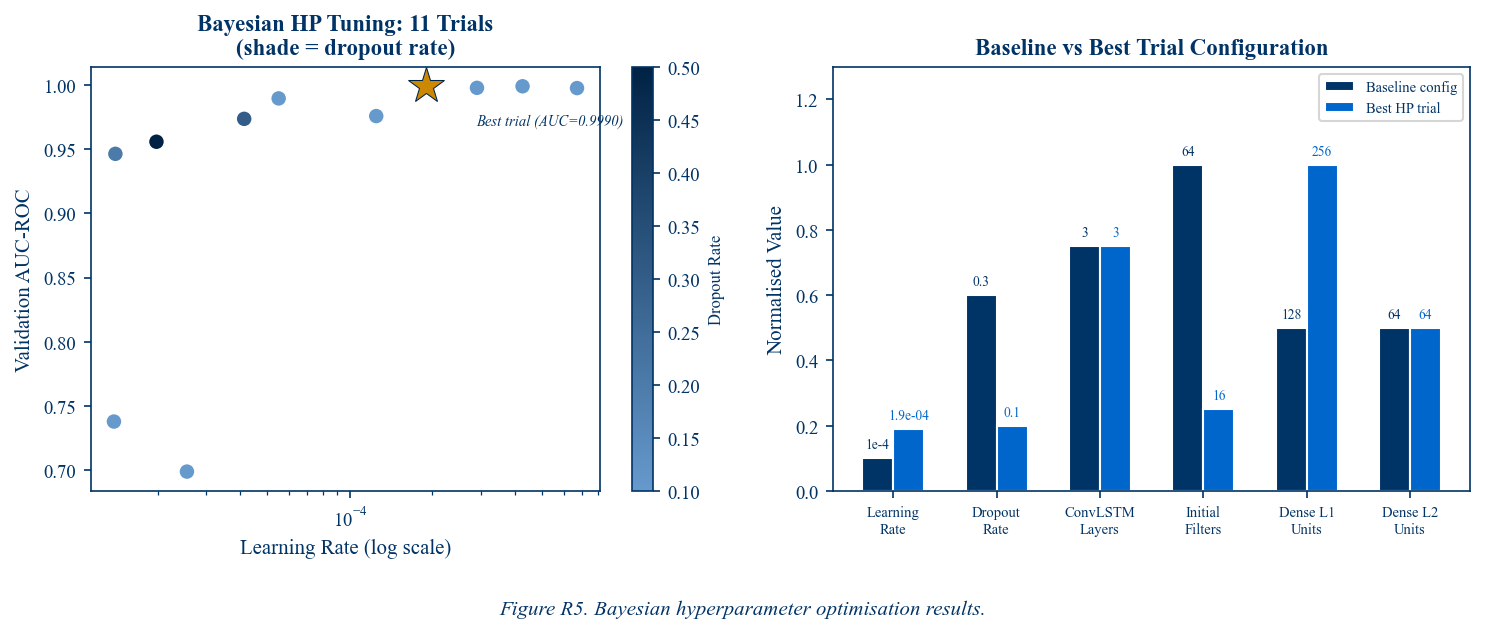

In [14]:
hp_df = pd.DataFrame(hp_trials)

hp_lr       = hp_df['learning_rate'].values
hp_val_auc  = hp_df['val_auc'].values
hp_dropout  = hp_df['dropout_rate'].values

best_idx = int(np.argmax(hp_val_auc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

ie_cmap = LinearSegmentedColormap.from_list('ie_blues', [BLUE_WASH, BLUE_DARK], N=256)
sc = ax1.scatter(hp_lr, hp_val_auc, c=hp_dropout, cmap=ie_cmap, s=60,
                 edgecolors='white', linewidths=0.8, zorder=5)
ax1.plot(hp_lr[best_idx], hp_val_auc[best_idx], '*', color=ACCENT_GOLD, markersize=18, zorder=6,
         markeredgecolor=BLUE_DARK, markeredgewidth=0.5)
ax1.annotate(f'Best trial (AUC={hp_val_auc[best_idx]:.4f})',
             xy=(hp_lr[best_idx], hp_val_auc[best_idx]),
             xytext=(hp_lr[best_idx] + 1e-4, hp_val_auc[best_idx] - 0.03),
             fontsize=7, style='italic', color=BLUE)
ax1.set_xscale('log')
ax1.set_xlabel('Learning Rate (log scale)')
ax1.set_ylabel('Validation AUC-ROC')
ax1.set_title(f'Bayesian HP Tuning: {len(hp_trials)} Trials\n(shade = dropout rate)', fontweight='bold')
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Dropout Rate', fontsize=8)
cbar.ax.yaxis.set_tick_params(color=BLUE)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=BLUE)

best_hp = hp_df.iloc[best_idx]
params = ['Learning\nRate', 'Dropout\nRate', 'ConvLSTM\nLayers', 'Initial\nFilters', 'Dense L1\nUnits', 'Dense L2\nUnits']

# Baseline config (from configs/training_config.yaml + model_config.yaml)
baseline_raw = ['1e-4', '0.3', '3', '64', '128', '64']
best_raw     = [f"{best_hp['learning_rate']:.1e}", f"{best_hp['dropout_rate']:.1f}",
                str(int(best_hp['num_convlstm_layers'])), str(int(best_hp['initial_filters'])),
                str(int(best_hp['dense_1_units'])), str(int(best_hp['dense_2_units']))]

# Normalised values for visual comparison
baseline_norm = [1e-4/1e-3, 0.3/0.5, 3/4, 64/64, 128/256, 64/128]
best_norm     = [best_hp['learning_rate']/1e-3, best_hp['dropout_rate']/0.5,
                 best_hp['num_convlstm_layers']/4, best_hp['initial_filters']/64,
                 best_hp['dense_1_units']/256, best_hp['dense_2_units']/128]

x = np.arange(len(params))
bw = 0.3
bars_b = ax2.bar(x - bw/2, baseline_norm, bw, label='Baseline config', color=BLUE, edgecolor='white')
bars_t = ax2.bar(x + bw/2, best_norm, bw, label='Best HP trial', color=BLUE_LIGHT, edgecolor='white')

for bar, lbl in zip(bars_b, baseline_raw):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, lbl,
             ha='center', fontsize=6.5, color=BLUE)
for bar, lbl in zip(bars_t, best_raw):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, lbl,
             ha='center', fontsize=6.5, color=BLUE_LIGHT)

ax2.set_xticks(x)
ax2.set_xticklabels(params, fontsize=7)
ax2.set_ylabel('Normalised Value')
ax2.set_title('Baseline vs Best Trial Configuration', fontweight='bold')
ax2.legend(fontsize=7)
ax2.set_ylim(0, 1.3)

fig.suptitle('Figure R5. Bayesian hyperparameter optimisation results.',
             y=-0.03, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figR5_hp_tuning.png', bbox_inches='tight')
plt.show()

---
## Tables

In [43]:
def make_thesis_table(data, col_labels, row_labels=None, title='', col_widths=None, fontsize=9):
    """Create a publication-quality table matching thesis formatting."""
    n_rows = len(data)
    n_cols = len(col_labels)
    
    if col_widths is None:
        col_widths = [1.0 / n_cols] * n_cols
    
    fig_h = 0.5 + 0.35 * n_rows
    fig_w = max(8, n_cols * 1.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    
    table = ax.table(
        cellText=data,
        colLabels=col_labels,
        rowLabels=row_labels,
        cellLoc='center',
        loc='center',
        colWidths=col_widths,
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.5)
    
    for j in range(n_cols):
        cell = table[0, j]
        cell.set_facecolor(BLUE)
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_edgecolor('white')
    
    # Data rows: alternating white / pale IE Blue wash
    for i in range(1, n_rows + 1):
        for j in range(n_cols):
            cell = table[i, j]
            cell.set_edgecolor('#D5D8DC')
            cell.set_text_props(color=BLUE)
            if i % 2 == 0:
                cell.set_facecolor('#E8EFF5')
            else:
                cell.set_facecolor('white')
    
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold', pad=15, color=BLUE)
    
    return fig

---
## Table 1: Landscape Patch Descriptions

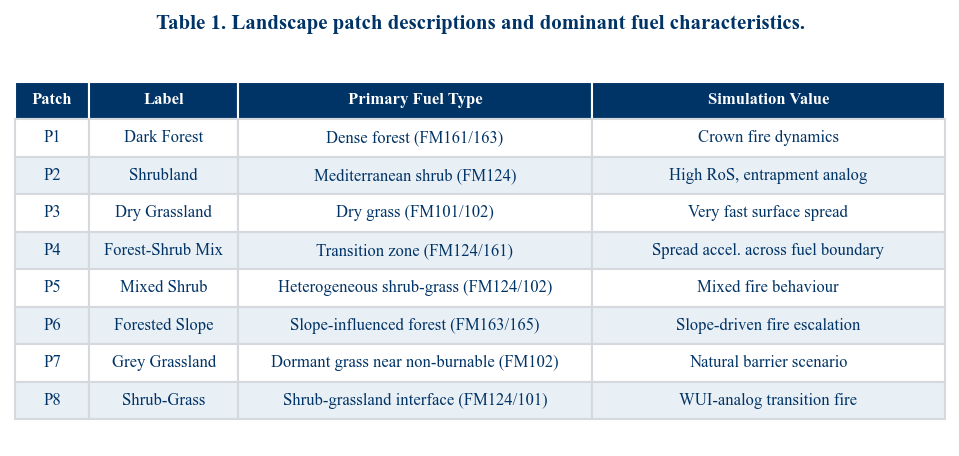

In [38]:
t1_data = [
    ['P1', 'Dark Forest', 'Dense forest (FM161/163)', 'Crown fire dynamics'],
    ['P2', 'Shrubland', 'Mediterranean shrub (FM124)', 'High RoS, entrapment analog'],
    ['P3', 'Dry Grassland', 'Dry grass (FM101/102)', 'Very fast surface spread'],
    ['P4', 'Forest-Shrub Mix', 'Transition zone (FM124/161)', 'Spread accel. across fuel boundary'],
    ['P5', 'Mixed Shrub', 'Heterogeneous shrub-grass (FM124/102)', 'Mixed fire behaviour'],
    ['P6', 'Forested Slope', 'Slope-influenced forest (FM163/165)', 'Slope-driven fire escalation'],
    ['P7', 'Grey Grassland', 'Dormant grass near non-burnable (FM102)', 'Natural barrier scenario'],
    ['P8', 'Shrub-Grass', 'Shrub-grassland interface (FM124/101)', 'WUI-analog transition fire'],
]
t1_cols = ['Patch', 'Label', 'Primary Fuel Type', 'Simulation Value']
fig = make_thesis_table(t1_data, t1_cols,
    title='Table 1. Landscape patch descriptions and dominant fuel characteristics.',
    col_widths=[0.08, 0.16, 0.38, 0.38], fontsize=8)
plt.savefig(FIG_DIR / 'table1_patches.png', bbox_inches='tight')
plt.show()

---
## Table 2: Weather Scenarios

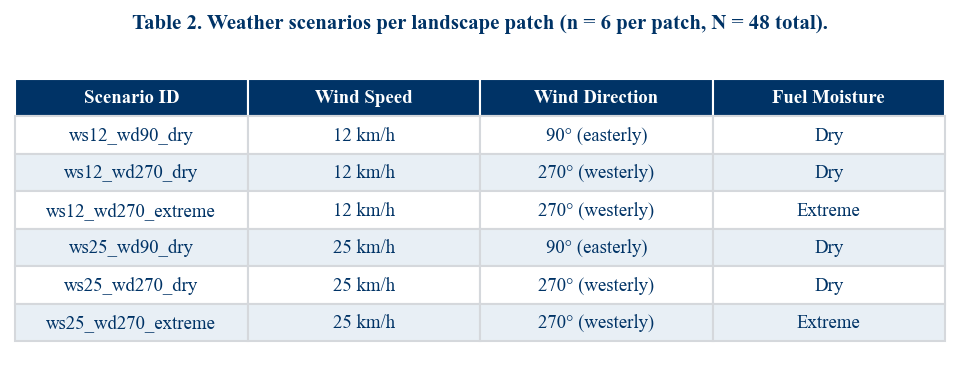

In [44]:
t2_data = [
    ['ws12_wd90_dry', '12 km/h', '90\u00b0 (easterly)', 'Dry'],
    ['ws12_wd270_dry', '12 km/h', '270\u00b0 (westerly)', 'Dry'],
    ['ws12_wd270_extreme', '12 km/h', '270\u00b0 (westerly)', 'Extreme'],
    ['ws25_wd90_dry', '25 km/h', '90\u00b0 (easterly)', 'Dry'],
    ['ws25_wd270_dry', '25 km/h', '270\u00b0 (westerly)', 'Dry'],
    ['ws25_wd270_extreme', '25 km/h', '270\u00b0 (westerly)', 'Extreme'],
]
t2_cols = ['Scenario ID', 'Wind Speed', 'Wind Direction', 'Fuel Moisture']
fig = make_thesis_table(t2_data, t2_cols, title='Table 2. Weather scenarios per landscape patch (n = 6 per patch, N = 48 total).')
plt.savefig(FIG_DIR / 'table2_weather.png', bbox_inches='tight')
plt.show()

---
## Table 3: ConvLSTM Architecture Summary

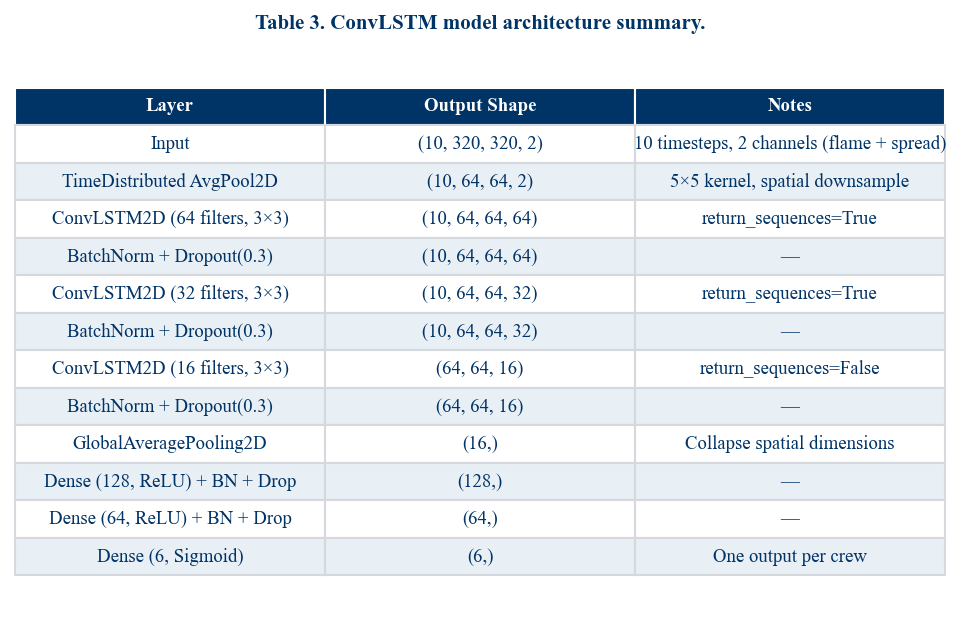

In [45]:
t3_data = [
    ['Input', '(10, 320, 320, 2)', '10 timesteps, 2 channels (flame + spread)'],
    ['TimeDistributed AvgPool2D', '(10, 64, 64, 2)', '5\u00d75 kernel, spatial downsample'],
    ['ConvLSTM2D (64 filters, 3\u00d73)', '(10, 64, 64, 64)', 'return_sequences=True'],
    ['BatchNorm + Dropout(0.3)', '(10, 64, 64, 64)', '\u2014'],
    ['ConvLSTM2D (32 filters, 3\u00d73)', '(10, 64, 64, 32)', 'return_sequences=True'],
    ['BatchNorm + Dropout(0.3)', '(10, 64, 64, 32)', '\u2014'],
    ['ConvLSTM2D (16 filters, 3\u00d73)', '(64, 64, 16)', 'return_sequences=False'],
    ['BatchNorm + Dropout(0.3)', '(64, 64, 16)', '\u2014'],
    ['GlobalAveragePooling2D', '(16,)', 'Collapse spatial dimensions'],
    ['Dense (128, ReLU) + BN + Drop', '(128,)', '\u2014'],
    ['Dense (64, ReLU) + BN + Drop', '(64,)', '\u2014'],
    ['Dense (6, Sigmoid)', '(6,)', 'One output per crew'],
]
t3_cols = ['Layer', 'Output Shape', 'Notes']
fig = make_thesis_table(t3_data, t3_cols, title='Table 3. ConvLSTM model architecture summary.')
plt.savefig(FIG_DIR / 'table3_architecture.png', bbox_inches='tight')
plt.show()

---
## Table 4: Dataset Statistics

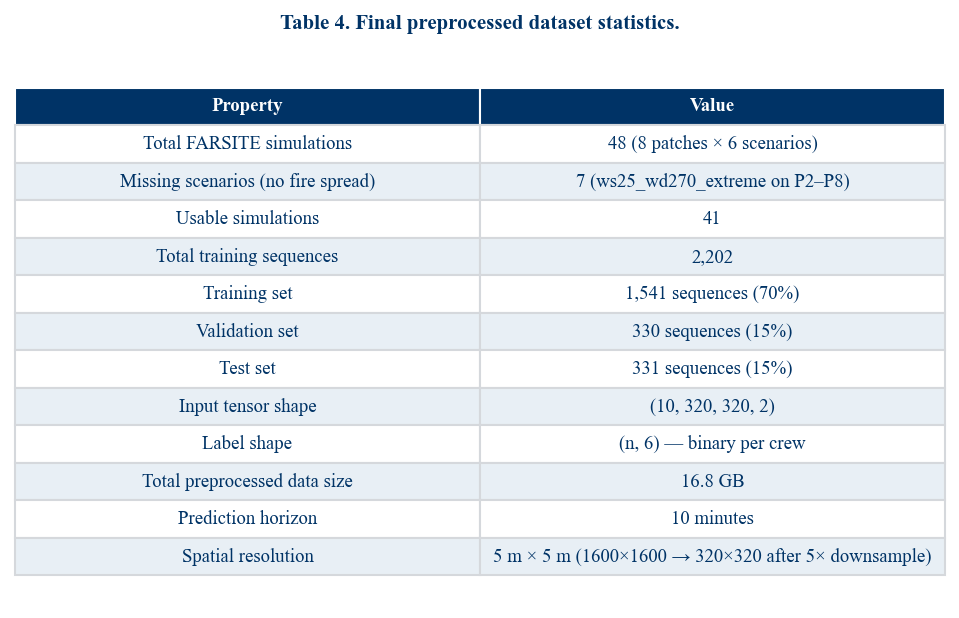

In [46]:
total_samples = 1541 + 330 + 331
n_missing = len(audit_summary.get('missing_scenarios', []))
t4_data = [
    ['Total FARSITE simulations', f'{audit_summary["total_simulations"]} (8 patches \u00d7 6 scenarios)'],
    ['Missing scenarios (no fire spread)', f'{n_missing} (ws25_wd270_extreme on P2\u2013P8)'],
    ['Usable simulations', f'{audit_summary["total_simulations"] - n_missing}'],
    ['Total training sequences', f'{total_samples:,}'],
    ['Training set', f'{1541:,} sequences (70%)'],
    ['Validation set', f'{330:,} sequences (15%)'],
    ['Test set', f'{331:,} sequences (15%)'],
    ['Input tensor shape', '(10, 320, 320, 2)'],
    ['Label shape', '(n, 6) \u2014 binary per crew'],
    ['Total preprocessed data size', '16.8 GB'],
    ['Prediction horizon', '10 minutes'],
    ['Spatial resolution', '5 m \u00d7 5 m (1600\u00d71600 \u2192 320\u00d7320 after 5\u00d7 downsample)'],
]
t4_cols = ['Property', 'Value']
fig = make_thesis_table(t4_data, t4_cols, title='Table 4. Final preprocessed dataset statistics.')
plt.savefig(FIG_DIR / 'table4_dataset.png', bbox_inches='tight')
plt.show()

---
## Table 5: Training Epoch Metrics

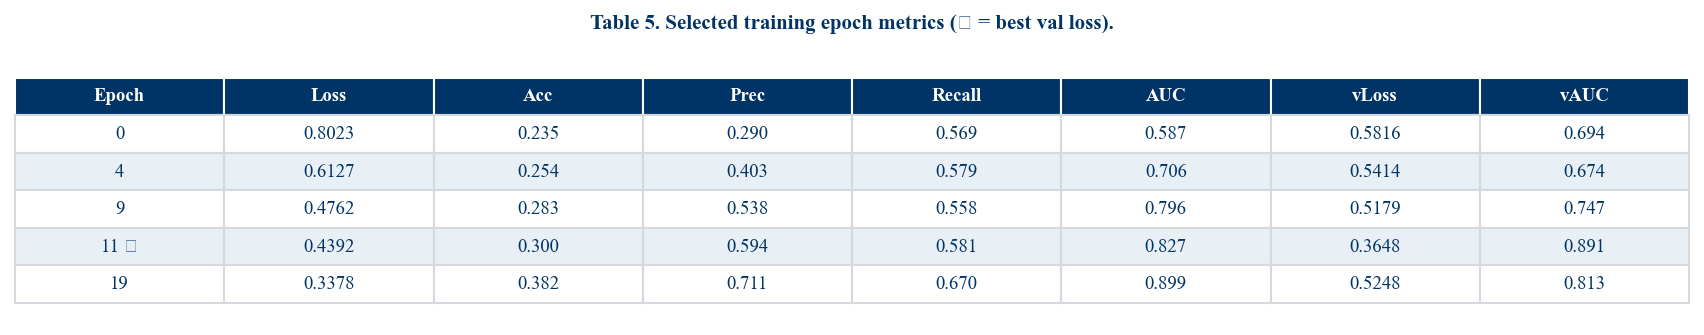

In [47]:
best_loss_ep = int(np.argmin(training_log['val_loss'].values))
selected_epochs = sorted(set([0, 4, 9, best_loss_ep, 19]))

t5_data = []
for ep in selected_epochs:
    row = training_log.iloc[ep]
    marker = ' \u2605' if ep == best_loss_ep else ''
    t5_data.append([
        f'{int(row["epoch"])}{marker}',
        f'{row["loss"]:.4f}',
        f'{row["accuracy"]:.3f}',
        f'{row["precision"]:.3f}',
        f'{row["recall"]:.3f}',
        f'{row["auc"]:.3f}',
        f'{row["val_loss"]:.4f}',
        f'{row["val_auc"]:.3f}',
    ])

t5_cols = ['Epoch', 'Loss', 'Acc', 'Prec', 'Recall', 'AUC', 'vLoss', 'vAUC']
fig = make_thesis_table(t5_data, t5_cols, title='Table 5. Selected training epoch metrics (\u2605 = best val loss).')
plt.savefig(FIG_DIR / 'table5_training.png', bbox_inches='tight')
plt.show()

---
## Table 6: Overall Test Performance

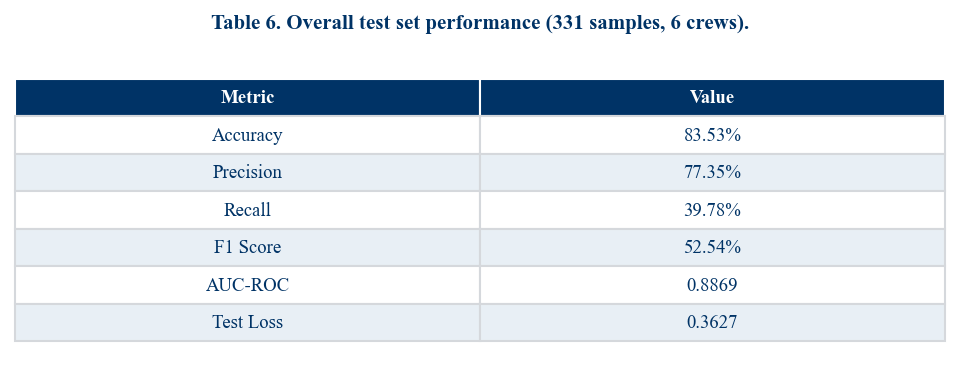

In [48]:
o = test_metrics['overall']
t6_data = [
    ['Accuracy',  f'{o["accuracy"]*100:.2f}%'],
    ['Precision', f'{o["precision"]*100:.2f}%'],
    ['Recall',    f'{o["recall"]*100:.2f}%'],
    ['F1 Score',  f'{o["f1_score"]*100:.2f}%'],
    ['AUC-ROC',   f'{o["auc_roc"]:.4f}'],
    ['Test Loss', f'{test_metrics["keras_metrics"]["loss"]:.4f}'],
]
t6_cols = ['Metric', 'Value']
fig = make_thesis_table(t6_data, t6_cols,
    title=f'Table 6. Overall test set performance ({o["num_samples"]} samples, {o["num_crews"]} crews).')
plt.savefig(FIG_DIR / 'table6_test.png', bbox_inches='tight')
plt.show()

---
## Table 7: Per-Crew Performance Breakdown

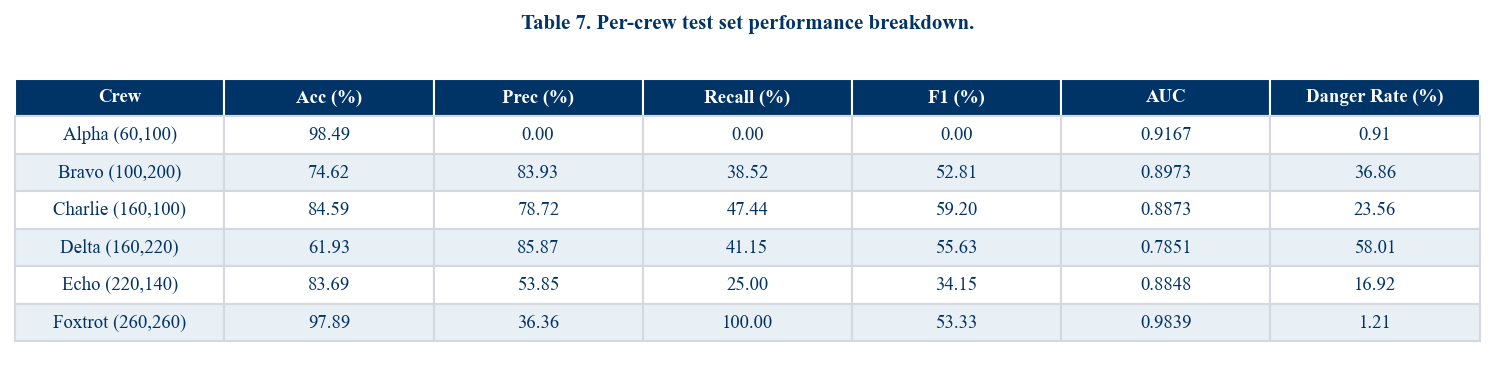

In [49]:
t7_data = []
for crew_name, m in test_metrics['per_crew'].items():
    t7_data.append([
        crew_name,
        f'{m["accuracy"]*100:.2f}',
        f'{m["precision"]*100:.2f}',
        f'{m["recall"]*100:.2f}',
        f'{m["f1_score"]*100:.2f}',
        f'{m["auc_roc"]:.4f}',
        f'{m["danger_rate"]*100:.2f}',
    ])

t7_cols = ['Crew', 'Acc (%)', 'Prec (%)', 'Recall (%)', 'F1 (%)', 'AUC', 'Danger Rate (%)']
fig = make_thesis_table(t7_data, t7_cols, title='Table 7. Per-crew test set performance breakdown.')
plt.savefig(FIG_DIR / 'table7_crew.png', bbox_inches='tight')
plt.show()

---
## Table 8: Baseline vs Best Hyperparameter Trial

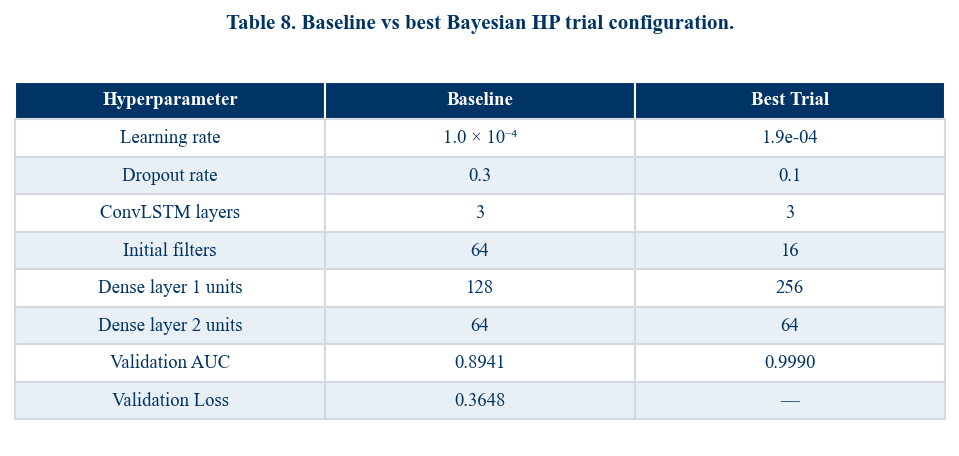

In [50]:
best_hp = hp_df.iloc[int(np.argmax(hp_df['val_auc'].values))]

baseline_val_auc = training_log['val_auc'].max()
baseline_val_loss = training_log['val_loss'].min()

t8_data = [
    ['Learning rate',       '1.0 \u00d7 10\u207b\u2074', f'{best_hp["learning_rate"]:.1e}'],
    ['Dropout rate',        '0.3',                         f'{best_hp["dropout_rate"]:.1f}'],
    ['ConvLSTM layers',     '3',                           f'{int(best_hp["num_convlstm_layers"])}'],
    ['Initial filters',     '64',                          f'{int(best_hp["initial_filters"])}'],
    ['Dense layer 1 units', '128',                         f'{int(best_hp["dense_1_units"])}'],
    ['Dense layer 2 units', '64',                          f'{int(best_hp["dense_2_units"])}'],
    ['Validation AUC',      f'{baseline_val_auc:.4f}',     f'{best_hp["val_auc"]:.4f}'],
    ['Validation Loss',     f'{baseline_val_loss:.4f}',    '\u2014'],
]
t8_cols = ['Hyperparameter', 'Baseline', 'Best Trial']
fig = make_thesis_table(t8_data, t8_cols, title='Table 8. Baseline vs best Bayesian HP trial configuration.')
plt.savefig(FIG_DIR / 'table8_hp.png', bbox_inches='tight')
plt.show()